In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!git clone https://github.com/moonlightaliza/text-to-sql-transformer.git

Cloning into 'text-to-sql-transformer'...
remote: Enumerating objects: 135, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 135 (delta 64), reused 105 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (135/135), 764.86 KiB | 4.47 MiB/s, done.
Resolving deltas: 100% (64/64), done.


In [3]:
%cd text-to-sql-transformer

/content/text-to-sql-transformer


In [4]:
!pip install -q sentencepiece records babel tqdm tabulate

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.8 MB/s eta 0:00:00


In [5]:
!git clone https://github.com/salesforce/WikiSQL

Cloning into 'WikiSQL'...
remote: Enumerating objects: 389, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 389 (delta 186), reused 154 (delta 154), pack-reused 194 (from 1)
Receiving objects: 100% (389/389), 50.72 MiB | 26.10 MiB/s, done.
Resolving deltas: 100% (213/213), done.


In [6]:
torch.cuda.is_available()

True

In [7]:
!wget https://github.com/salesforce/WikiSQL/raw/master/data.tar.bz2

--2026-10-05 08:19:30--  https://github.com/salesforce/WikiSQL/raw/master/data.tar.bz2
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/salesforce/WikiSQL/master/data.tar.bz2 [following]
--2026-10-05 08:19:31--  https://raw.githubusercontent.com/salesforce/WikiSQL/master/data.tar.bz2
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26164664 (25M) [application/octet-stream]
Saving to: ‘data.tar.bz2’

data.tar.bz2        100%[===================>]  24.95M  41.9MB/s    in 0.6s    

2026-10-05 08:19:33 (41.9 MB/s) - ‘data.tar.bz2’ saved [26164664/26164664]



In [8]:
!tar -xjf data.tar.bz2

In [9]:
!find /content/text-to-sql-transformer -name "train.tables.jsonl"

/content/text-to-sql-transformer/data/train.tables.jsonl


In [10]:
!find /content/text-to-sql-transformer -name "train.tables.jsonl"

/content/text-to-sql-transformer/data/train.tables.jsonl


In [11]:
!mkdir -p WikiSQL
!mv data WikiSQL/data

In [12]:
!python starter/data_prep.py

train: 56355 pairs
tell me what the notes are for south australia <sep> <c0> state/territory <c1> text/background colour <c2> format <c3> current slogan <c4> current series <c5> notes
select <c5> where <c3> = south australia
dev: 8421 pairs
what position does the player who played for butler cc (ks) play? <sep> <c0> player <c1> no. <c2> nationality <c3> position <c4> years in toronto <c5> school/club team
select <c3> where <c5> = butler cc (ks)
test: 15878 pairs
what is terrence ross' nationality <sep> <c0> player <c1> no. <c2> nationality <c3> position <c4> years in toronto <c5> school/club team
select <c2> where <c0> = terrence ross


In [13]:
!python -m starter.tokenizer

I0000 00:00:1791188384.946254     968 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: spm_corpus.txt
  input_format: 
  model_prefix: sql_sp
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <sep>
  user_defined_symbols: <c0>
  user_defined_symbols: <c1>
  user_defined_symbols: <c2>
  user_defined_symbols: <c3>
  user_defined_symbols: <c4>
  user_defined_symbols: <c5>
  user_defined_symbols: <c6>
  user_defined_symbols: <c7>
  user_defined_symbols: <c8>
  user_defined_symbols: <c9>
  user_defined_sym

In [14]:
!ls -lh sql_sp.model sql_sp.vocab

-rw-r--r-- 1 root root 353K Oct  5 08:19 sql_sp.model
-rw-r--r-- 1 root root 101K Oct  5 08:19 sql_sp.vocab


In [15]:
!git pull

Already up to date.


In [16]:
%%time
!python train.py 2>&1 | tee train_log.txt

train_pairs.jsonl: kept 56336, skipped 19
dev_pairs.jsonl: kept 8421, skipped 0
Device: cuda
Parameters: 7,585,600
Epoch 01/20 | Train Loss: 4.4534 | Dev Loss: 2.9992 | LR: 2.176536e-04
Saved best checkpoint.
Epoch 02/20 | Train Loss: 2.6412 | Dev Loss: 2.2281 | LR: 4.353073e-04
Saved best checkpoint.
Epoch 03/20 | Train Loss: 2.1350 | Dev Loss: 1.9484 | LR: 6.529609e-04
Saved best checkpoint.
Epoch 04/20 | Train Loss: 1.8978 | Dev Loss: 1.8145 | LR: 8.706146e-04
Saved best checkpoint.
Epoch 05/20 | Train Loss: 1.7879 | Dev Loss: 1.7480 | LR: 9.416881e-04
Saved best checkpoint.
Epoch 06/20 | Train Loss: 1.6938 | Dev Loss: 1.6655 | LR: 8.596396e-04
Saved best checkpoint.
Epoch 07/20 | Train Loss: 1.6214 | Dev Loss: 1.6308 | LR: 7.958717e-04
Saved best checkpoint.
Epoch 08/20 | Train Loss: 1.5714 | Dev Loss: 1.5891 | LR: 7.444698e-04
Saved best checkpoint.
Epoch 09/20 | Train Loss: 1.5310 | Dev Loss: 1.5509 | LR: 7.018928e-04
Saved best checkpoint.
Epoch 10/20 | Train Loss: 1.4978 | Dev 

In [17]:
!ls -lh checkpoints/

total 88M
-rw-r--r-- 1 root root 88M Oct  5 08:39 best.pt


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
!mkdir -p /content/drive/MyDrive/text_to_sql_checkpoints
!cp checkpoints/best.pt /content/drive/MyDrive/text_to_sql_checkpoints/best.pt

mkdir: cannot create directory ‘/content/drive/MyDrive/text_to_sql_checkpoints’: Input/output error
cp: cannot create regular file '/content/drive/MyDrive/text_to_sql_checkpoints/best.pt': No such file or directory


In [20]:
!ls -lh /content/drive/MyDrive/text_to_sql_checkpoints/

ls: cannot access '/content/drive/MyDrive/text_to_sql_checkpoints/': No such file or directory


In [21]:
!ls -lh checkpoints/

total 88M
-rw-r--r-- 1 root root 88M Oct  5 08:39 best.pt


In [27]:
import re
import pandas as pd

pat = re.compile(
    r'Epoch\s+(\d+)\s*/\s*\d+.*?Train Loss[:\s]+([\d.]+).*?Dev Loss[:\s]+([\d.]+).*?LR[:\s]+([\d.eE+-]+)'
)
rows = []
with open('train_log.txt') as f:
    for line in f:
        m = pat.search(line)
        if m:
            e, tr, dv, lr = m.groups()
            rows.append((int(e), float(tr), float(dv), float(lr)))

df = pd.DataFrame(rows, columns=['epoch', 'train_loss', 'dev_loss', 'learning_rate'])
assert len(df) > 0, 'Regex matched nothing; check the log line format'
df.to_csv('training_results.csv', index=False)

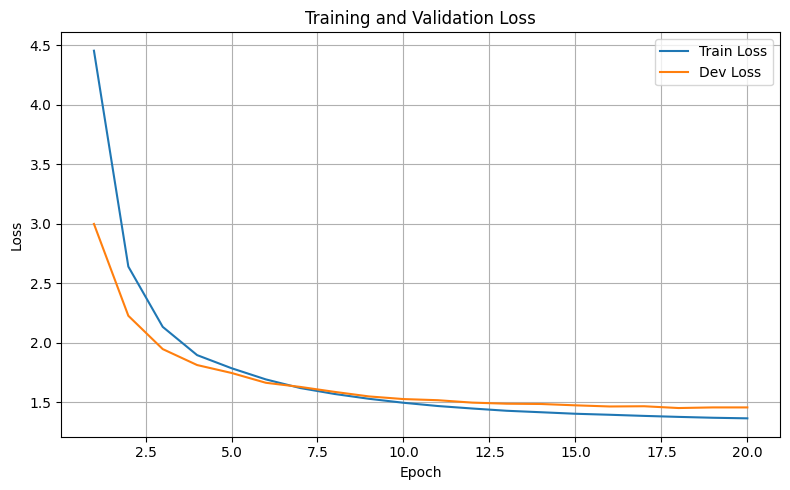

Best epoch: 18
Best dev loss: 1.4535


In [28]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

CSV_PATHS = [
    'training_results.csv',
    '/content/drive/MyDrive/text_to_sql/artifacts/training_results.csv',
]
csv_path = next((p for p in CSV_PATHS if os.path.exists(p)), None)
if csv_path is None:
    raise FileNotFoundError(f'No results CSV found in: {CSV_PATHS}')

df = pd.read_csv(csv_path).sort_values('epoch').reset_index(drop=True)

plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
plt.plot(df['epoch'], df['dev_loss'], label='Dev Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig('loss_curve.png', dpi=300)
plt.show()

best = df.loc[df['dev_loss'].idxmin()]
print(f"Best epoch: {int(best['epoch'])}")
print(f"Best dev loss: {best['dev_loss']:.4f}")

In [29]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/drive/MyDrive/text_to_sql_artifacts

!cp training_results.csv /content/drive/MyDrive/text_to_sql_artifacts/
!cp loss_curve.png /content/drive/MyDrive/text_to_sql_artifacts/
!cp sql_sp.model /content/drive/MyDrive/text_to_sql_artifacts/
!cp sql_sp.vocab /content/drive/MyDrive/text_to_sql_artifacts/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
!ls -lh /content/drive/MyDrive/text_to_sql_artifacts/

total 568K
-rw------- 1 root root 114K Oct  5 08:49 loss_curve.png
-rw------- 1 root root 353K Oct  5 08:49 sql_sp.model
-rw------- 1 root root 101K Oct  5 08:49 sql_sp.vocab
-rw------- 1 root root  621 Oct  5 08:49 training_results.csv
